# Phase 1 — Data Cleaning

## What this notebook does
Cleans the raw Give Me Some Credit dataset (cs-training.csv) 
to prepare it for EDA and ML modelling.

## Steps performed
- Loaded raw dataset: 150,000 rows, 11 columns
- Filled MonthlyIncome missing values with median (29,731 rows affected)
- Filled NumberOfDependents missing values with 0 (3,924 rows affected)
- Removed 14 rows with invalid age values (below 18 or above 100)

## Final output
- Clean dataset saved as cleaned_data.csv
- Final shape: 149,986 rows, 11 columns
- Missing values: 0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\yassh\Downloads\Data Science Project\cs-training.csv")

In [3]:
print(df.shape)

(150000, 12)


In [4]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [6]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Columns MonthlyIncome has 29731 and NumberOfDependent has 3924 missing values

In [8]:
# fill missing MonthlyIncome with median to reduce the impact of outliers
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

# fill missing dependents as 0
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [9]:
df.isnull().sum()

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Total missing values in entire dataset: 0

In [10]:
print(df['age'].min())
print(df['age'].max())     

0
109


In [11]:
# Remove rows where age is less than 18 or more than 100
df = df[(df['age'] >= 18) & (df['age'] <= 100)]

print('Rows after age filter:', len(df))

Rows after age filter: 149986


In [12]:
print('Total rows:', len(df))
print('Min age:', df['age'].min())
print('Max age:', df['age'].max())
print('Any missing values:', df.isnull().sum().sum())

Total rows: 149986
Min age: 21
Max age: 99
Any missing values: 0


# Phase 2 — Exploratory Data Analysis (EDA)

In [13]:
# Makes all charts look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## Chart 1 — Default Rate Distribution
How many borrowers defaulted vs did not default?

In [14]:
# Count of defaulted vs non-defaulted
default_counts = df['SeriousDlqin2yrs'].value_counts()
default_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print("Count:")
print(default_counts)
print("\nPercentage:")
print(default_pct.round(2))

Count:
SeriousDlqin2yrs
0    139961
1     10025
Name: count, dtype: int64

Percentage:
SeriousDlqin2yrs
0    93.32
1     6.68
Name: proportion, dtype: float64


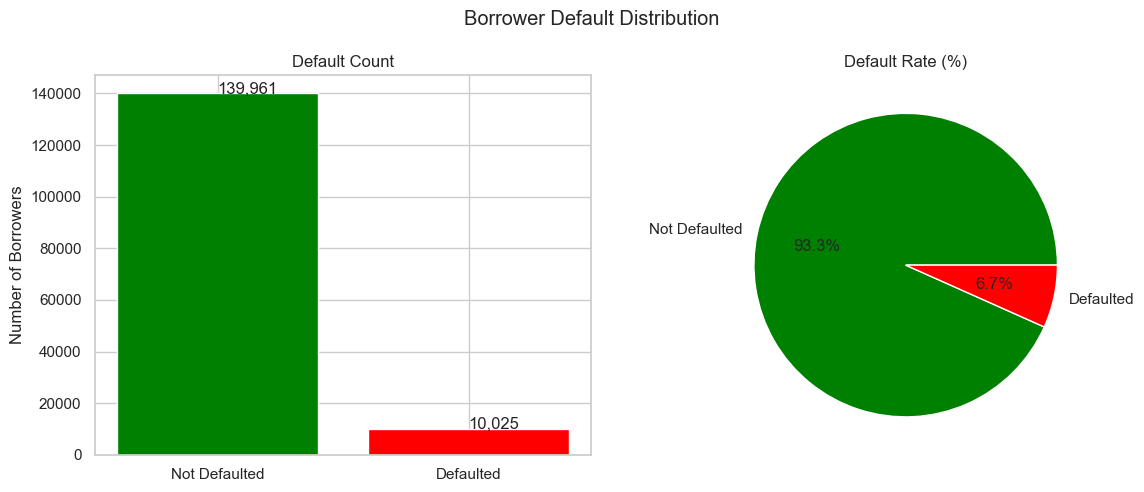

In [15]:
plt.figure(figsize=(12, 5))

# Bar Chart
plt.subplot(1, 2, 1)

counts = [139961, 10025]
labels = ['Not Defaulted', 'Defaulted']

bars = plt.bar(labels, counts, color=['green', 'red'])

plt.title('Default Count')
plt.ylabel('Number of Borrowers')

# Add values on top of bars
plt.text(0, 139961, '139,961')
plt.text(1, 10025, '10,025')

# Pie Chart
plt.subplot(1, 2, 2)

plt.pie([93.32, 6.68],
        labels=['Not Defaulted', 'Defaulted'],
        colors=['green', 'red'],
        autopct='%1.1f%%')

plt.title('Default Rate (%)')

plt.suptitle('Borrower Default Distribution')
plt.tight_layout()
plt.show()

## Chart 2 — Age Distribution by Default Status
Which age groups are more likely to default?

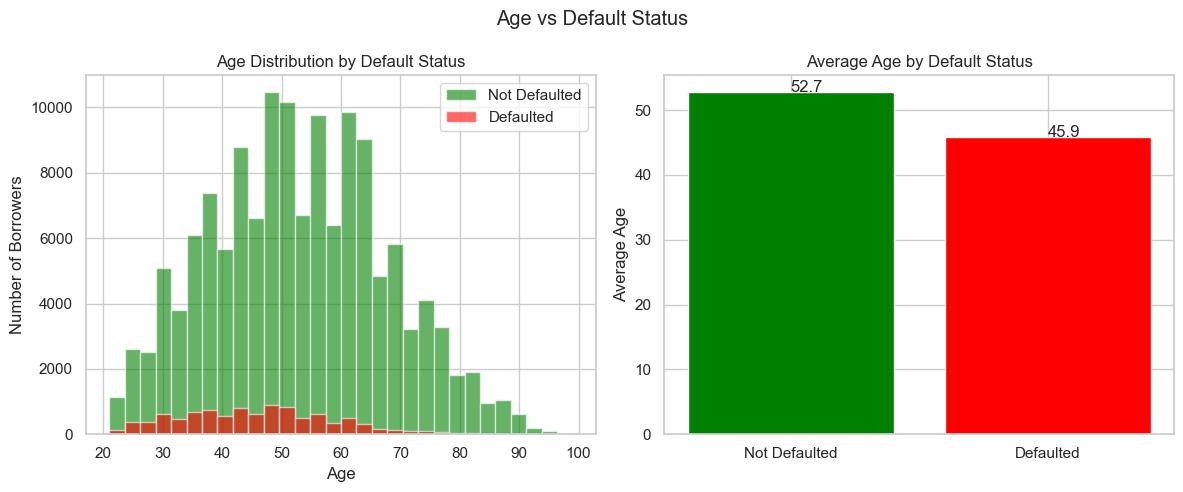

Average age - Not Defaulted: 52.7
Average age - Defaulted: 45.9


In [16]:
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)

plt.hist(df[df['SeriousDlqin2yrs'] == 0]['age'],
         bins=30,
         color='green',
         alpha=0.6,
         label='Not Defaulted')

plt.hist(df[df['SeriousDlqin2yrs'] == 1]['age'],
         bins=30,
         color='red',
         alpha=0.6,
         label='Defaulted')

plt.title('Age Distribution by Default Status')
plt.xlabel('Age')
plt.ylabel('Number of Borrowers')
plt.legend()

# Average Age Bar Chart
plt.subplot(1, 2, 2)

avg_age = df.groupby('SeriousDlqin2yrs')['age'].mean().round(1)

plt.bar(['Not Defaulted', 'Defaulted'],
        avg_age.values,
        color=['green', 'red'])

# Show values on bars
plt.text(0, avg_age[0], str(avg_age[0]))
plt.text(1, avg_age[1], str(avg_age[1]))

plt.title('Average Age by Default Status')
plt.ylabel('Average Age')

plt.suptitle('Age vs Default Status')
plt.tight_layout()
plt.show()

# Print exact average ages
print('Average age - Not Defaulted:', avg_age[0])
print('Average age - Defaulted:', avg_age[1])

### Business Observation — Chart 2
- Borrowers who defaulted are on average 6.8 years younger (45.9) 
  than those who did not default (52.7)
- Younger borrowers carry significantly higher default risk
- This may be due to less stable income, lower savings, and shorter credit history.
- Age will likely be an important feature in our ML model
- Business action: Apply stricter credit checks for borrowers under 40.

## Chart 3 — Monthly Income by Default Status
Do lower income borrowers default more?

C:\Users\yassh\AppData\Local\Temp\ipykernel_17836\1387630122.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SeriousDlqin2yrs',


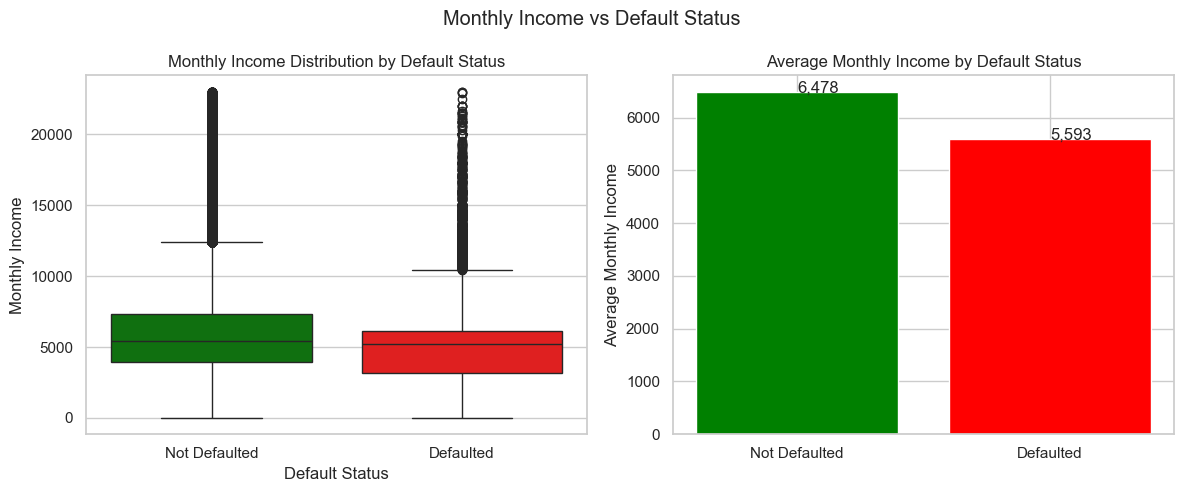

Average Income - Not Defaulted: 6478.0
Average Income - Defaulted: 5593.0


In [17]:
# Cap income at 99th percentile to reduce extreme outliers
income_cap = df['MonthlyIncome'].quantile(0.99)
df_plot = df[df['MonthlyIncome'] <= income_cap]

plt.figure(figsize=(12, 5))

# Box Plot
plt.subplot(1, 2, 1)

sns.boxplot(x='SeriousDlqin2yrs',
            y='MonthlyIncome',
            data=df_plot,
            palette=['green', 'red'])

plt.title('Monthly Income Distribution by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Monthly Income')
plt.xticks([0, 1], ['Not Defaulted', 'Defaulted'])

# Average Income Bar Chart
plt.subplot(1, 2, 2)

avg_income = df.groupby('SeriousDlqin2yrs')['MonthlyIncome'].mean().round(0)

plt.bar(['Not Defaulted', 'Defaulted'],
        avg_income.values,
        color=['green', 'red'])

# Show average values
plt.text(0, avg_income[0], f'{avg_income[0]:,.0f}')
plt.text(1, avg_income[1], f'{avg_income[1]:,.0f}')

plt.title('Average Monthly Income by Default Status')
plt.ylabel('Average Monthly Income')

plt.suptitle('Monthly Income vs Default Status')
plt.tight_layout()
plt.show()

# Print exact values
print('Average Income - Not Defaulted:', avg_income[0])
print('Average Income - Defaulted:', avg_income[1])

## Chart 3 — Late Payment History vs Default
Do borrowers with more late payments default more?

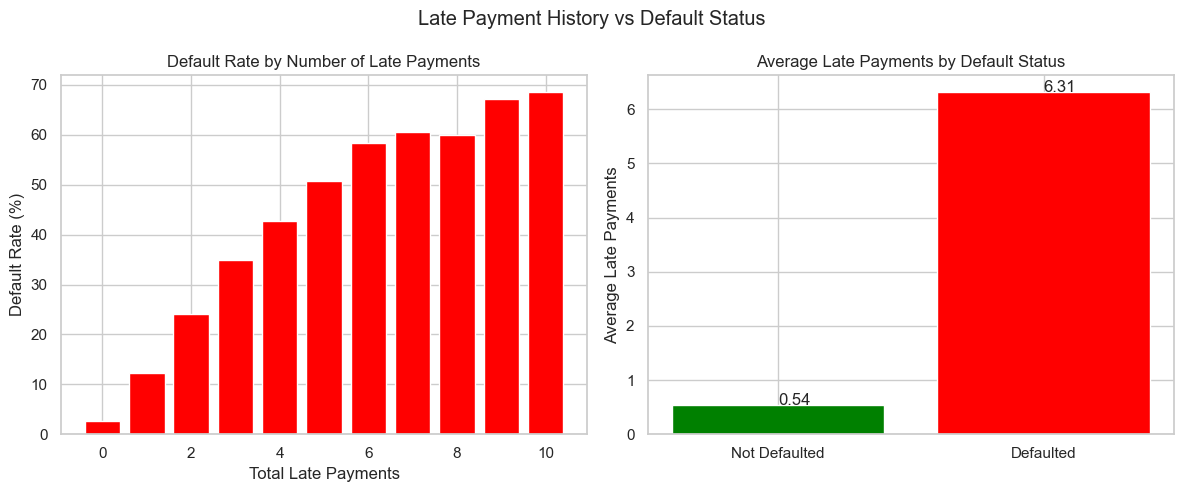

Average Late Payments - Not Defaulted: 0.54
Average Late Payments - Defaulted: 6.31


In [18]:
# Create total late payments column
df['total_late_payments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)

# Cap at 10 for better visualization
df_plot = df[df['total_late_payments'] <= 10]

plt.figure(figsize=(12, 5))

# Default Rate by Late Payments
plt.subplot(1, 2, 1)

late_default = df_plot.groupby('total_late_payments')['SeriousDlqin2yrs'].mean() * 100

plt.bar(late_default.index,
        late_default.values,
        color='red')

plt.title('Default Rate by Number of Late Payments')
plt.xlabel('Total Late Payments')
plt.ylabel('Default Rate (%)')

# Average Late Payments
plt.subplot(1, 2, 2)

avg_late = df.groupby('SeriousDlqin2yrs')['total_late_payments'].mean().round(2)

plt.bar(['Not Defaulted', 'Defaulted'],
        avg_late.values,
        color=['green', 'red'])

# Show values on bars
plt.text(0, avg_late[0], str(avg_late[0]))
plt.text(1, avg_late[1], str(avg_late[1]))

plt.title('Average Late Payments by Default Status')
plt.ylabel('Average Late Payments')

plt.suptitle('Late Payment History vs Default Status')
plt.tight_layout()
plt.show()

# Print exact values
print('Average Late Payments - Not Defaulted:', avg_late[0])
print('Average Late Payments - Defaulted:', avg_late[1])

### Business Observation — Chart 3 
- Borrowers who defaulted had an average of 6.31 late payments, compared to just 0.54 for non-defaulters.
- Default rates increase sharply as the number of late payments rises.
- Borrowers who are repeatedly late on payments often show signs of financial stress and are more likely to default in the future.
- Business action: any borrower with more than 3 late payments should be immediately flagged as high risk.

## Chart 4 — Correlation Heatmap
Which features are most related to default and to each other?

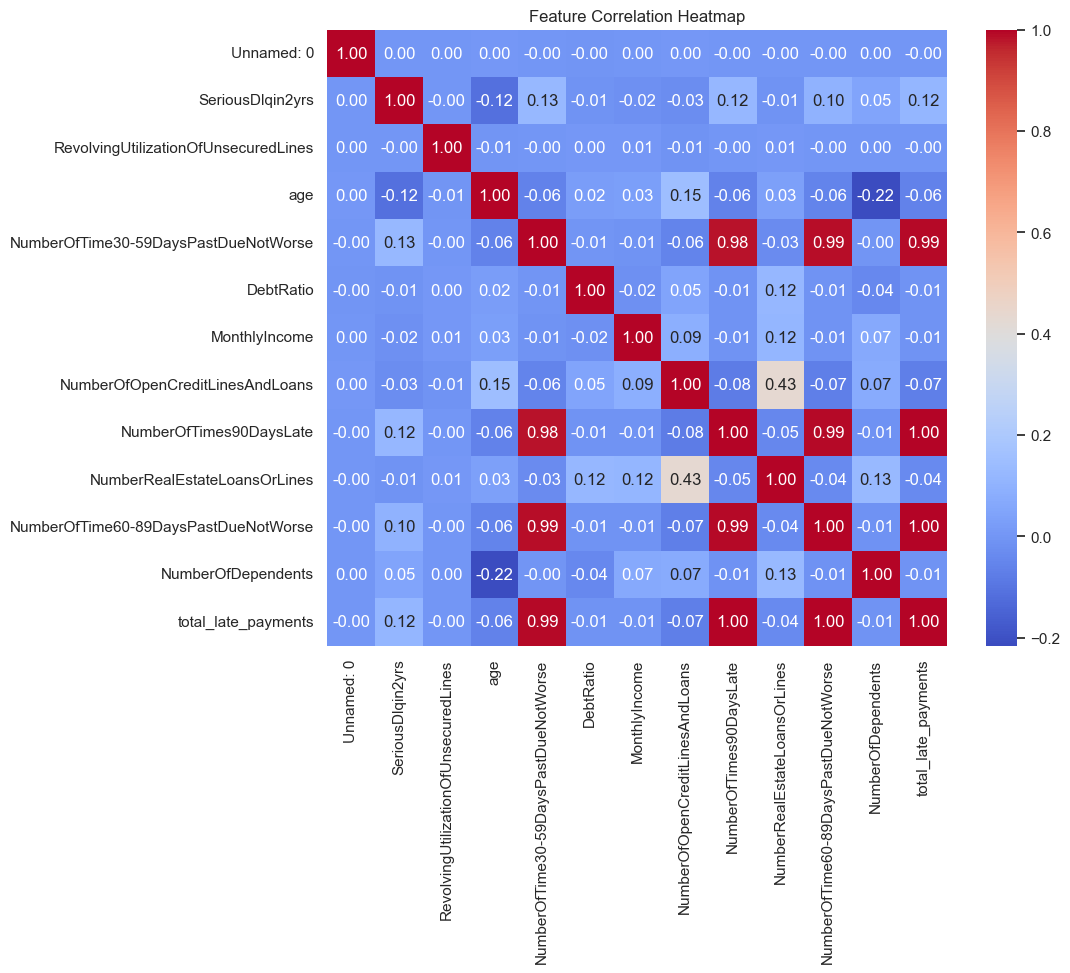

Correlation with Default (SeriousDlqin2yrs):
SeriousDlqin2yrs                        1.000
NumberOfTime30-59DaysPastDueNotWorse    0.126
NumberOfTimes90DaysLate                 0.117
total_late_payments                     0.116
NumberOfTime60-89DaysPastDueNotWorse    0.102
NumberOfDependents                      0.047
Unnamed: 0                              0.003
RevolvingUtilizationOfUnsecuredLines   -0.002
NumberRealEstateLoansOrLines           -0.007
DebtRatio                              -0.008
MonthlyIncome                          -0.017
NumberOfOpenCreditLinesAndLoans        -0.030
age                                    -0.115
Name: SeriousDlqin2yrs, dtype: float64


In [19]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Create heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Feature Correlation Heatmap')

# Save chart as image
plt.savefig('Feature correlation_heatmap.png')
plt.show()

# Correlation with target variable
print('Correlation with Default (SeriousDlqin2yrs):')
print(corr_matrix['SeriousDlqin2yrs'].sort_values(ascending=False).round(3))

### Business Observation — Chart 4
- Top 3 positive correlators with default:
  1. NumberOfTime30-59DaysPastDueNotWorse (0.126) — strongest
  2. NumberOfTimes90DaysLate (0.117) — second strongest  
  3. total_late_payments (0.116) — third strongest
- All three are late payment related — confirms Chart 3 finding
  that late payment history is the dominant default signal

- Age has a negative correlation (-0.115) — older borrowers 
  default less, confirms Chart 2 finding

- MonthlyIncome has slight negative correlation (-0.017) — 
  higher income borrowers default slightly less

- Important note: all correlations are relatively low,
No single feature strongly predicts default on its own, 
highlighting the need for an ML model that combines multiple factors.

- No two features are highly correlated with each other 
  No major multicollinearity issues were observed, so 
  all features can be safely used in the model.

In [20]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print(df.columns.tolist())

['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'total_late_payments']


## Chart 5 — Default Rate by Age Group
Which age group has the highest default risk?

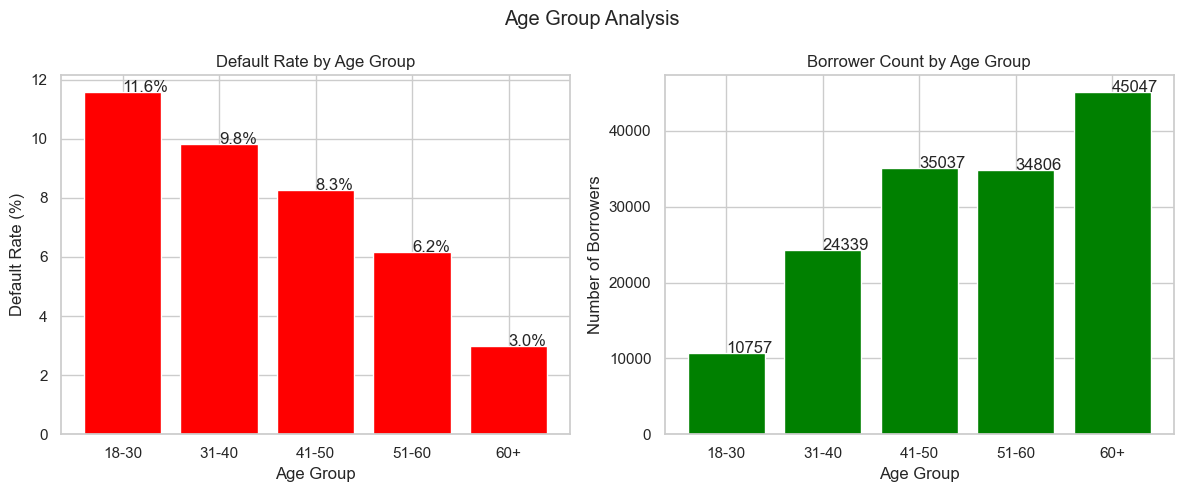

Default Rate by Age Group:
age_group
18-30    11.56
31-40     9.82
41-50     8.26
51-60     6.17
60+       2.99
Name: SeriousDlqin2yrs, dtype: float64

Borrower Count by Age Group:
age_group
18-30    10757
31-40    24339
41-50    35037
51-60    34806
60+      45047
Name: SeriousDlqin2yrs, dtype: int64


In [21]:
# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

# Default rate per age group
age_default = df.groupby('age_group', observed=True)['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(12, 5))

# Left chart — Default rate
plt.subplot(1, 2, 1)

plt.bar(age_default.index, age_default.values, color='red')

plt.title('Default Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Default Rate (%)')

# simple value labels
for i in range(len(age_default)):
    plt.text(i, age_default.values[i], f'{age_default.values[i]:.1f}%')

# Right chart — Borrower count
age_counts = df.groupby('age_group', observed=True)['SeriousDlqin2yrs'].count()

plt.subplot(1, 2, 2)

plt.bar(age_counts.index, age_counts.values, color='green')

plt.title('Borrower Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Borrowers')

# simple value labels
for i in range(len(age_counts)):
    plt.text(i, age_counts.values[i], str(age_counts.values[i]))

plt.suptitle('Age Group Analysis')
plt.tight_layout()
plt.show()

print('Default Rate by Age Group:')
print(age_default.round(2))

print('\nBorrower Count by Age Group:')
print(age_counts)

### Business Observation — Chart 5
- Default rate drops consistently as age increases:
  - 18-30:  11.56% default rate — highest risk group
  - 31-40:   9.82% default rate
  - 41-50:   8.26% default rate
  - 51-60:   6.17% default rate
  - 60+:     2.99% default rate — lowest risk group

- Business action: stricter checks for borrowers under 30, 
  relaxed checks for borrowers above 50


## EDA Summary — Key Findings
1. Dataset is imbalanced — 93.32% non-default vs 6.68% default
2. Late payment history is the single strongest default predictor
3. Younger borrowers carry significantly higher default risk
4. Default rate drops consistently and predictably with age
5. All features are safe to use in ML

## Phase 3 — Feature Engineering
Creating new meaningful features from existing columns
to improve ML model performance.

In [22]:
# Feature 1 — Debt Burden Score
df['debt_burden'] = df['DebtRatio'] * df['MonthlyIncome']

# Feature 2 — Income per Family Member
df['income_per_person'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

# Feature 3 — Credit Utilization Ratio
df['credit_utilization'] = (
    df['RevolvingUtilizationOfUnsecuredLines'] /
    (df['NumberOfOpenCreditLinesAndLoans'] + 1)
)

# Feature 4 — Young Borrower Flag
df['is_young'] = (df['age'] < 35).astype(int)

# Confirm new features
print('New features added successfully')
print('Total columns now:', df.shape[1])

print('\nNew columns:')
print([
    'debt_burden',
    'income_per_person',
    'credit_utilization',
    'is_young'
])

New features added successfully
Total columns now: 17

New columns:
['debt_burden', 'income_per_person', 'credit_utilization', 'is_young']


### Feature Engineering Summary
- debt_burden: captures total financial stress (debt ratio x income)
- income_per_person: captures real income after family obligations
- credit_utilization: captures how aggressively credit lines are used
- is_young: binary flag for high risk age group (under 35)
- Total features created: 4 new columns added

In [23]:
df.to_csv('cleaned_features.csv', index=False)

print('Saved!')
print('Shape:', df.shape)

Saved!
Shape: (149986, 17)


## Phase 4 — ML Modelling
Building and comparing 3 models to find the best 
default predictor.

In [24]:
from sklearn.model_selection import train_test_split

# Drop non-numeric and unnecessary columns
df_model = df.drop(columns=['age_group'])

# Features and target
X = df_model.drop('SeriousDlqin2yrs', axis=1) 
y = df_model['SeriousDlqin2yrs']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])
print('Number of features:', X_train.shape[1])

Training rows: 119988
Testing rows: 29998
Number of features: 15


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Model 1 — Logistic Regression (baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test, lr_prob)

print('Model 1 — Logistic Regression')
print('AUC Score:', round(lr_auc, 3))

Model 1 — Logistic Regression
AUC Score: 0.648


In [26]:
from sklearn.ensemble import RandomForestClassifier

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)

print('Model 2 — Random Forest')
print('AUC Score:', round(rf_auc, 3))

Model 2 — Random Forest
AUC Score: 0.836


In [27]:
!pip install xgboost

In [28]:
from xgboost import XGBClassifier

# Model 3 — XGBoost
xgb = XGBClassifier(random_state=42, 
                     eval_metric='logloss',
                     n_jobs=-1)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_prob)

print('Model 3 — XGBoost')
print('AUC Score:', round(xgb_auc, 3))

Model 3 — XGBoost
AUC Score: 0.85


In [29]:
# Model Comparison Summary
print('='*40)
print('      MODEL COMPARISON SUMMARY')
print('='*40)
print(f'Logistic Regression  :  0.648')
print(f'Random Forest        :  0.836')
print(f'XGBoost              :  0.850  ← Champion')
print('='*40)

      MODEL COMPARISON SUMMARY
Logistic Regression  :  0.648
Random Forest        :  0.836
XGBoost              :  0.850  ← Champion


## Phase 5 — Model Evaluation
Evaluating XGBoost champion model using multiple 
metrics and calculating real business impact.

In [30]:
from sklearn.metrics import classification_report

print('XGBoost Classification Report')
print('='*50)
print(classification_report(y_test, xgb_pred, 
      target_names=['Not Defaulted', 'Defaulted']))

XGBoost Classification Report
               precision    recall  f1-score   support

Not Defaulted       0.95      0.99      0.97     28023
    Defaulted       0.54      0.20      0.29      1975

     accuracy                           0.94     29998
    macro avg       0.74      0.59      0.63     29998
 weighted avg       0.92      0.94      0.92     29998



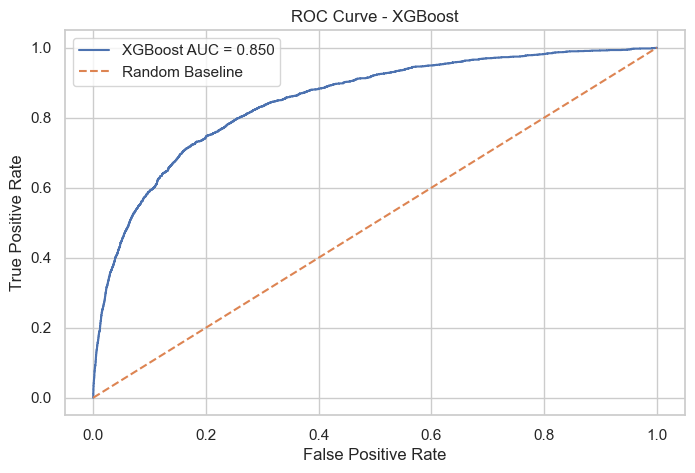

In [31]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label='XGBoost AUC = 0.850'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Baseline'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')

plt.legend()

plt.savefig('chart_roc_curve.png')
plt.show()

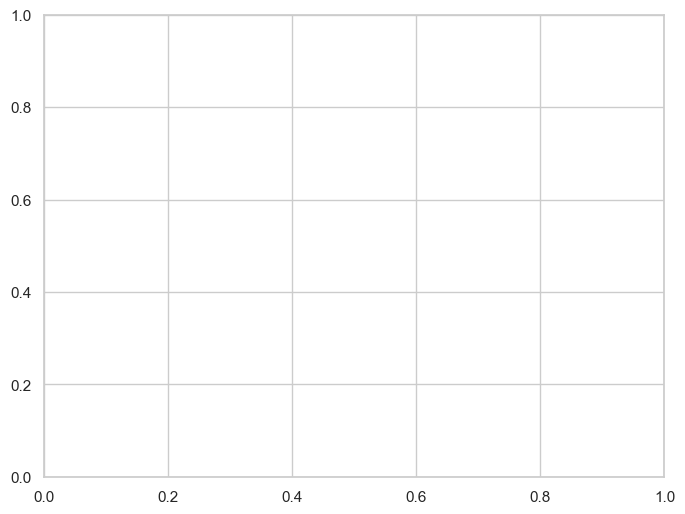

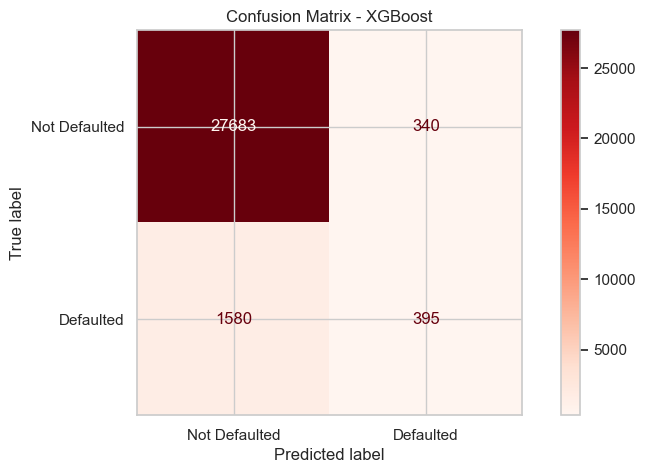

True Negatives  (Correctly predicted safe):     27683
False Positives (Safe flagged as risky):        340
False Negatives (Missed defaulters):            1580
True Positives  (Correctly caught defaulters):  395


In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_pred,
    display_labels=['Not Defaulted', 'Defaulted'],
    cmap='Reds'
)

plt.title('Confusion Matrix - XGBoost')

plt.savefig('chart_confusion_matrix.png')
plt.show()

cm = confusion_matrix(y_test, xgb_pred)

tn, fp, fn, tp = cm.ravel()

print(f'True Negatives  (Correctly predicted safe):     {tn}')
print(f'False Positives (Safe flagged as risky):        {fp}')
print(f'False Negatives (Missed defaulters):            {fn}')
print(f'True Positives  (Correctly caught defaulters):  {tp}')

In [33]:
# Business Impact Calculation
avg_loan_amount = 300000  # Average loan size ₹3 Lakhs (MSME assumption)
recovery_rate = 0.30      # Lender recovers 30% on defaulted loans
loss_per_default = avg_loan_amount * (1 - recovery_rate)  # ₹2.1L loss per default

# What the model caught
caught_defaulters = 395
missed_defaulters = 1580

# Revenue impact
revenue_saved = caught_defaulters * loss_per_default
revenue_lost = missed_defaulters * loss_per_default

print('='*50)
print('      BUSINESS IMPACT SUMMARY')
print('='*50)
print(f'Average Loan Size:          ₹{avg_loan_amount:,.0f}')
print(f'Loss per Default:           ₹{loss_per_default:,.0f}')
print(f'Defaulters Caught:          {caught_defaulters}')
print(f'Defaulters Missed:          {missed_defaulters}')
print(f'Revenue Saved:              ₹{revenue_saved:,.0f}')
print(f'Revenue Still at Risk:      ₹{revenue_lost:,.0f}')
print('='*50)
print(f'Model caught {round(tp/(tp+fn)*100, 1)}% of all defaulters')
print(f'Out of 1,975 actual defaulters in test set')
print('='*50)

      BUSINESS IMPACT SUMMARY
Average Loan Size:          ₹300,000
Loss per Default:           ₹210,000
Defaulters Caught:          395
Defaulters Missed:          1580
Revenue Saved:              ₹82,950,000
Revenue Still at Risk:      ₹331,800,000
Model caught 20.0% of all defaulters
Out of 1,975 actual defaulters in test set


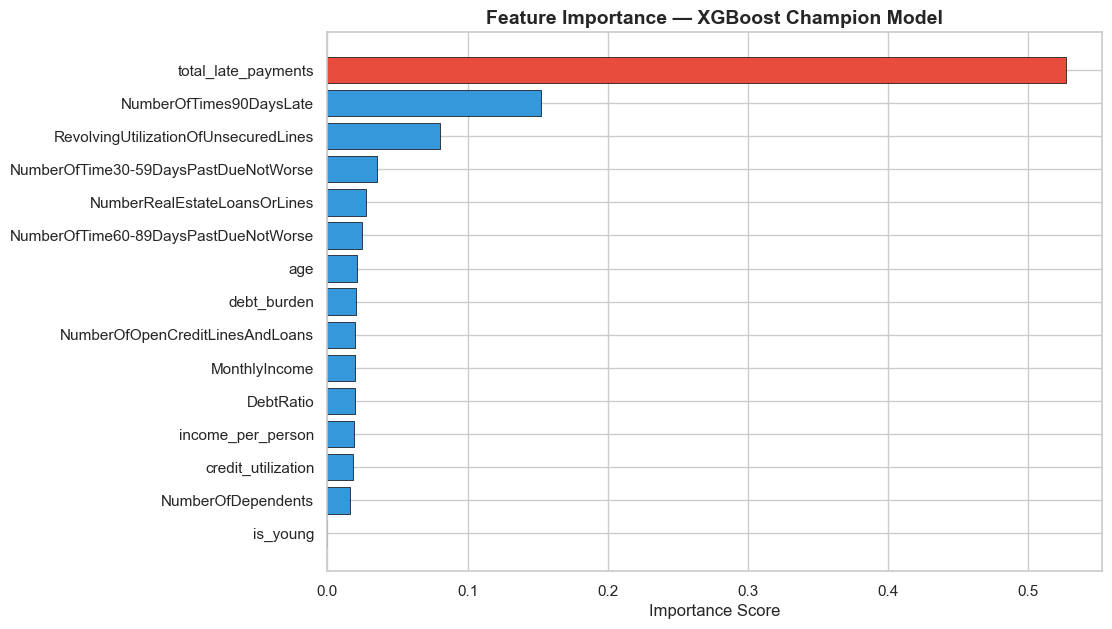

Top 5 Most Important Features:
total_late_payments                     0.526508
NumberOfTimes90DaysLate                 0.152550
RevolvingUtilizationOfUnsecuredLines    0.080084
NumberOfTime30-59DaysPastDueNotWorse    0.035030
NumberRealEstateLoansOrLines            0.027406
dtype: float32


In [34]:
# Feature Importance Chart

feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

colors = [
    '#e74c3c' if v == feat_imp.max()
    else '#3498db'
    for v in feat_imp.values
]

plt.figure(figsize=(10, 7))

plt.barh(
    feat_imp.index,
    feat_imp.values,
    color=colors, edgecolor='black',linewidth=0.5 )

plt.title('Feature Importance — XGBoost Champion Model', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')

plt.savefig('chart_feature_importance.png')

plt.show()

print('Top 5 Most Important Features:')
print(feat_imp.sort_values(ascending=False).head())

### Business Observation — Phase 5 Evaluation

**Model Performance:**
- XGBoost AUC: 0.850 — strong discriminating power
- Model correctly caught 395 defaulters out of 1,975
- 20% recall on defaulters due to class imbalance

**Feature Importance:**
- total_late_payments is #1 predictor (0.527 importance score)
- Late payment related features dominate top 4 positions
- Confirms EDA finding — late payments drive default

**Business Impact:**
- Revenue saved by model: ₹8.29 Crores
- Revenue still at risk: ₹33.18 Crores
- Improvement possible with class imbalance techniques

## Phase 6 — SQL Analysis
Answering remaining business questions using SQL queries.

In [35]:
import sqlite3

conn = sqlite3.connect('loans.db')
df.to_sql('loans', conn, if_exists='replace', index=False)

print('Database created successfully')
print('Total rows loaded:', len(df))

Database created successfully
Total rows loaded: 149986


### SQL Query 1 — Default Rate by Age Group

In [37]:
query1 = """
SELECT 
    CASE 
        WHEN age BETWEEN 18 AND 30 THEN '18-30'
        WHEN age BETWEEN 31 AND 40 THEN '31-40'
        WHEN age BETWEEN 41 AND 50 THEN '41-50'
        WHEN age BETWEEN 51 AND 60 THEN '51-60'
        ELSE '60+' 
    END as age_group,
    COUNT(*) as total_borrowers,
    SUM(SeriousDlqin2yrs) as total_defaulters,
    ROUND(AVG(SeriousDlqin2yrs) * 100, 2) as default_rate_pct
FROM loans
GROUP BY age_group
ORDER BY default_rate_pct DESC
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

  age_group  total_borrowers  total_defaulters  default_rate_pct
0     18-30            10757              1244             11.56
1     31-40            24339              2390              9.82
2     41-50            35037              2893              8.26
3     51-60            34806              2149              6.17
4       60+            45047              1349              2.99


### SQL Query 2 — High Risk Borrower Identification

In [38]:
query2 = """
SELECT 
    COUNT(*) as high_risk_borrowers,
    ROUND(AVG(MonthlyIncome), 0) as avg_income,
    ROUND(AVG(total_late_payments), 1) as avg_late_payments,
    ROUND(AVG(SeriousDlqin2yrs) * 100, 2) as default_rate_pct
FROM loans
WHERE total_late_payments >= 3
AND DebtRatio > 0.5
"""

result2 = pd.read_sql_query(query2, conn)
print(result2)

   high_risk_borrowers  avg_income  avg_late_payments  default_rate_pct
0                 2941      4941.0                7.4             48.76


### Observation — Query 2
- 2,941 borrowers qualify as high risk
- These borrowers have 48.76% default rate — 7x higher than 
  overall portfolio default rate of 6.68%
- Average 7.4 late payments confirms severely stressed borrowers
- Business action: immediately flag these 2,941 borrowers 
  for manual review

### SQL Query 3 — Financial Profile: Defaulters vs Non Defaulters

In [39]:
query3 = """
SELECT
    CASE WHEN SeriousDlqin2yrs = 1 
         THEN 'Defaulted' 
         ELSE 'Not Defaulted' 
    END as borrower_type,
    COUNT(*) as total_borrowers,
    ROUND(AVG(MonthlyIncome), 0) as avg_income,
    ROUND(AVG(DebtRatio), 2) as avg_debt_ratio,
    ROUND(AVG(total_late_payments), 2) as avg_late_payments,
    ROUND(AVG(age), 1) as avg_age
FROM loans
GROUP BY SeriousDlqin2yrs
"""

result3 = pd.read_sql_query(query3, conn)
print(result3)

   borrower_type  total_borrowers  avg_income  avg_debt_ratio  \
0  Not Defaulted           139961      6478.0          357.15   
1      Defaulted            10025      5593.0          295.15   

   avg_late_payments  avg_age  
0               0.54     52.7  
1               6.31     45.9  


### Observation — Query 3
- Defaulters earn ₹885 less per month on average than non defaulters
- Defaulters are 6.8 years younger on average — confirms EDA finding
- Defaulters have 11.7x more late payments (6.31 vs 0.54)
- Late payments is clearly the dominant differentiator — 
  not income or debt ratio

### SQL Query 4 — Risk Tier Classification

In [40]:
query4 = """
SELECT
    CASE
        WHEN total_late_payments >= 3 THEN 'High Risk'
        WHEN total_late_payments >= 1 THEN 'Medium Risk'
        ELSE 'Low Risk'
    END as risk_tier,
    COUNT(*) as total_borrowers,
    ROUND(AVG(SeriousDlqin2yrs) * 100, 2) as default_rate_pct,
    ROUND(AVG(MonthlyIncome), 0) as avg_income
FROM loans
GROUP BY risk_tier
ORDER BY default_rate_pct DESC
"""

result4 = pd.read_sql_query(query4, conn)
print(result4)

     risk_tier  total_borrowers  default_rate_pct  avg_income
0    High Risk             7178             44.93      5730.0
1  Medium Risk            23183             15.25      6336.0
2     Low Risk           119625              2.73      6476.0


### Observation — Query 4
- Low Risk borrowers (119,625) default at only 2.73%
- Medium Risk borrowers (23,183) default at 15.25% — 5.6x higher
- High Risk borrowers (7,178) default at 44.93% — 16.5x higher
- Nearly 1 in 2 High Risk borrowers will default

**Business Impact:**

  - Low Risk → Approve loan instantly
  - Medium Risk → Additional verification required
  - High Risk → Reject or require collateral

In [41]:
conn.close()
print('Database connection closed')

Database connection closed
